## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [5]:
df=pd.read_csv('hotel_bookings.csv')

## Exploratory Data Analysis and Data Cleaning 

In [4]:
df.sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30668,Resort Hotel,0,14,2017,March,13,30,0,2,2,...,No Deposit,6.0,NaN,0,Transient,60.00,0,1,Check-Out,1/4/2017
107148,City Hotel,0,137,2017,March,10,6,1,1,2,...,No Deposit,37.0,NaN,0,Transient-Party,80.00,0,1,Check-Out,8/3/2017
70396,City Hotel,1,131,2017,June,24,16,1,2,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,3,Canceled,10/3/2017
80477,City Hotel,1,25,2015,December,50,8,0,2,1,...,Non Refund,19.0,NaN,0,Transient,90.00,0,0,Canceled,17/11/2015
61659,City Hotel,1,531,2016,December,52,22,0,2,2,...,Non Refund,1.0,NaN,0,Transient,62.80,0,0,Canceled,21/10/2015
84768,City Hotel,0,18,2016,February,10,28,2,2,3,...,No Deposit,9.0,NaN,0,Transient,130.00,0,2,Check-Out,3/3/2016
67863,City Hotel,1,287,2017,May,19,8,1,3,2,...,No Deposit,9.0,NaN,0,Transient,116.33,0,1,Canceled,20/1/2017
102150,City Hotel,0,14,2016,November,47,18,2,3,0,...,No Deposit,25.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,23/11/2016
76600,City Hotel,0,138,2015,July,30,25,0,1,2,...,No Deposit,1.0,NaN,0,Transient-Party,60.00,0,0,Check-Out,26/7/2015
118908,City Hotel,0,30,2017,August,34,25,0,2,2,...,No Deposit,7.0,NaN,0,Transient,145.00,0,1,Check-Out,27/8/2017


In [9]:
df.shape

(119390, 32)

In [11]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
#reservation_status_date column type should be date
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'],dayfirst=True)

In [8]:
#Getting information about categorical data
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [20]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

hotel
['Resort Hotel' 'City Hotel']
--------------------------------------------------
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
--------------------------------------------------
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'J

In [21]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df.drop(['company','agent'],axis=1, inplace=True)
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [26]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


{'whiskers': [<matplotlib.lines.Line2D at 0x29fca88db50>,
 'caps': [<matplotlib.lines.Line2D at 0x29fca89e0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x29fca88d8b0>],
 'medians': [<matplotlib.lines.Line2D at 0x29fca89e5b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x29fca89e850>],
 'means': []}

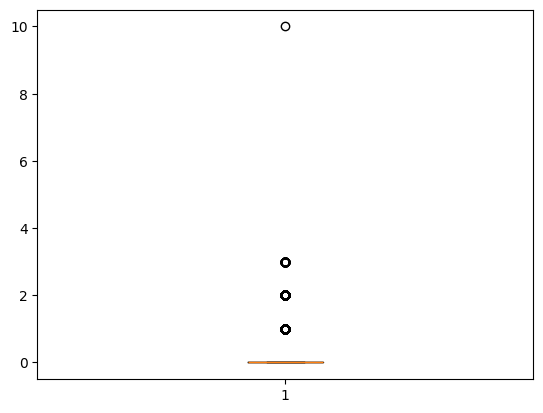

In [34]:
#df['children'].plot(kind='box')
plt.boxplot(df['children'])

In [4]:
df=df[df['children']<10]

In [41]:
df['babies'].value_counts()

babies
0    117983
1       898
2        14
Name: count, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x29fcaadbe50>,
 'caps': [<matplotlib.lines.Line2D at 0x29fcaaee3d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x29fcaadbbb0>],
 'medians': [<matplotlib.lines.Line2D at 0x29fcaaee910>],
 'fliers': [<matplotlib.lines.Line2D at 0x29fcaaeebb0>],
 'means': []}

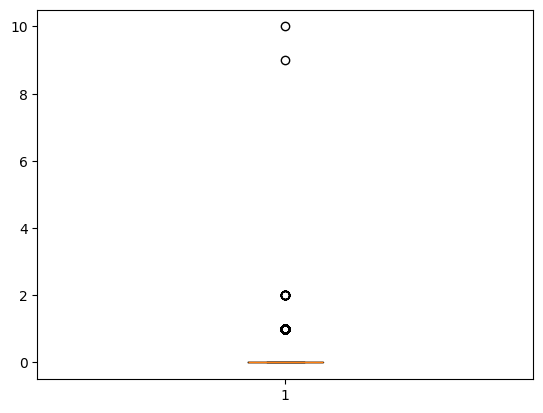

In [36]:
plt.boxplot(df['babies'])

In [37]:
df=df[df['babies']<8]

In [40]:
df['babies'].value_counts()

babies
0    117983
1       898
2        14
Name: count, dtype: int64

In [45]:
df['is_repeated_guest'].value_counts()

is_repeated_guest
0    115089
1      3806
Name: count, dtype: int64

In [5]:
df['previous_cancellations'].value_counts()

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
19        19
5         19
14        14
13        12
21         1
Name: count, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x202c82ac7f0>,
 'caps': [<matplotlib.lines.Line2D at 0x202c82acd30>,
 'boxes': [<matplotlib.lines.Line2D at 0x202c82ac550>],
 'medians': [<matplotlib.lines.Line2D at 0x202c82ca2b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x202c82ca550>],
 'means': []}

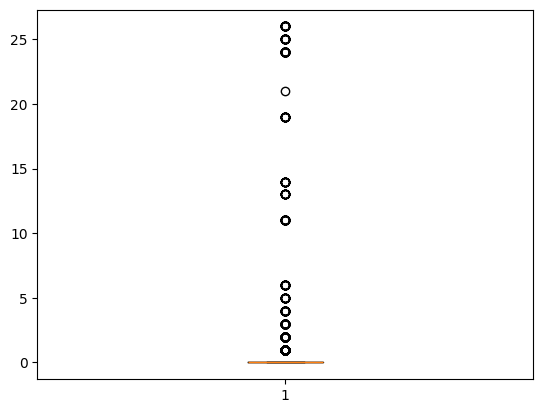

In [6]:
plt.boxplot(df['previous_cancellations'])

In [10]:
max(df['adults'])


55

In [9]:
max(df['children'])

10.0

{'whiskers': [<matplotlib.lines.Line2D at 0x202ce016430>,
 'caps': [<matplotlib.lines.Line2D at 0x202ce016970>,
 'boxes': [<matplotlib.lines.Line2D at 0x202ce016190>],
 'medians': [<matplotlib.lines.Line2D at 0x202ce016eb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x202ce055190>],
 'means': []}

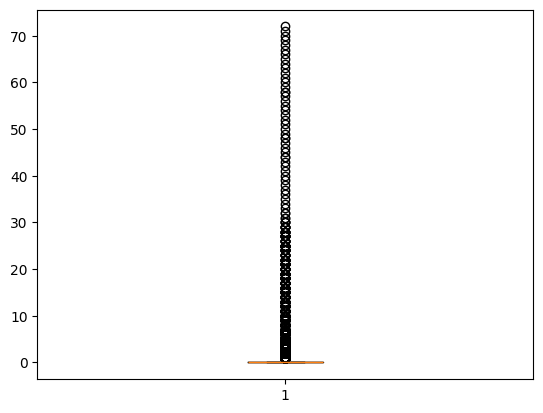

In [13]:
plt.boxplot(df['previous_bookings_not_canceled'])

In [16]:
df['previous_bookings_not_canceled'].value_counts()

previous_bookings_not_canceled
0     115770
1       1542
2        580
3        333
4        229
       ...  
47         1
49         1
50         1
51         1
72         1
Name: count, Length: 73, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x202ce171d90>,
 'caps': [<matplotlib.lines.Line2D at 0x202ce180310>,
 'boxes': [<matplotlib.lines.Line2D at 0x202ce171af0>],
 'medians': [<matplotlib.lines.Line2D at 0x202ce180730>],
 'fliers': [<matplotlib.lines.Line2D at 0x202ce1809d0>],
 'means': []}

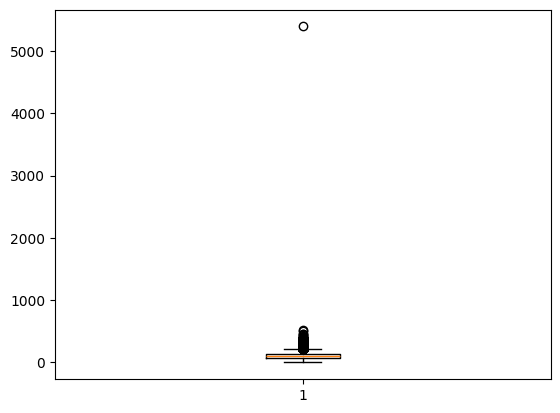

In [17]:
plt.boxplot(df['adr'])

In [11]:
df=df[df['adr']<5000]

In [12]:
df['adr'].value_counts()

adr
62.00     3753
75.00     2710
90.00     2471
65.00     2397
0.00      1938
          ... 
31.71        1
41.52        1
64.18        1
11.75        1
157.71       1
Name: count, Length: 8869, dtype: int64

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,0.032011,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,0.176030,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN


## Data Analysis and Visualization

In [14]:
canceled_perc=df['is_canceled'].value_counts(normalize=True)
canceled_perc

is_canceled
0    0.628653
1    0.371347
Name: proportion, dtype: float64

#### 37% of cancelation is way too much high

<BarContainer object of 2 artists>

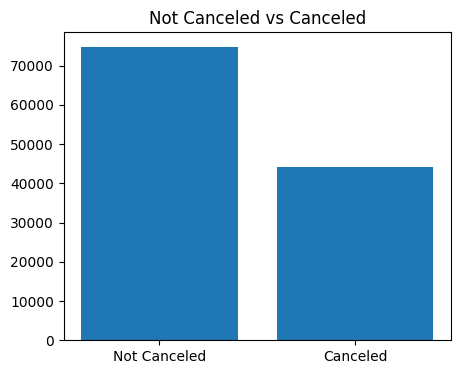

In [39]:
plt.figure(figsize=(5,4))
plt.title('Not Canceled vs Canceled')
plt.bar(['Not Canceled','Canceled'],df['is_canceled'].value_counts().sort_index())

Text(0.5, 1.0, 'Cancelation rate: Resort Hotel vs City Hotel')

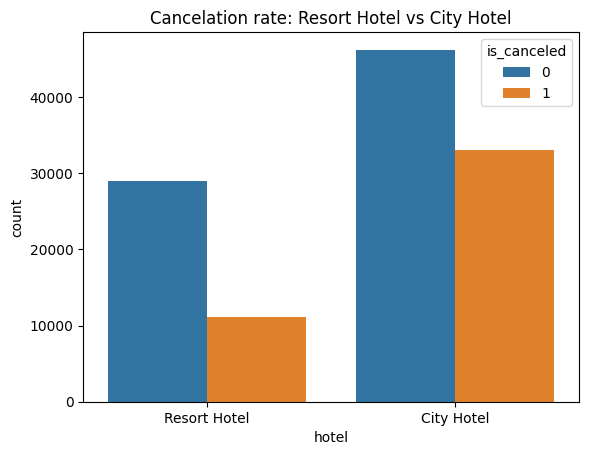

In [35]:
sns.countplot(data=df,x='hotel',hue='is_canceled')
plt.title('Cancelation rate: Resort Hotel vs City Hotel')

#### In Resort Hotel cancelation is less comparitively

In [16]:
# Checking the percentage of canceled and not canceled for each hotel 
resort_hotel=df[df['hotel']=='Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.72025
1    0.27975
Name: proportion, dtype: float64

In [17]:
city_hotel=df[df['hotel']=='City Hotel']
city_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.582918
1    0.417082
Name: proportion, dtype: float64

#### 41% of cancelation is too much for city hotels

In [7]:
# for checking how price affects on cancelation 
# Grouping by reservation_status_date bcs on a single day multiple reseravations has done 
# So for every single day we are taking avg of adr

#### ADR stands for Average Daily Rate. 
#### It represents the average amount of money a guest pays per night for a booked room.
#### It’s a measure of how much revenue the hotel earns per occupied room, excluding any free stays or empty rooms.

In [18]:
resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean().sort_index()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean().sort_index()

In [8]:
resort_hotel

,adr
reservation_status_date,
2014-11-18,0.000000
2015-01-01,61.966667
2015-01-02,9.633750
2015-01-18,0.000000
2015-01-21,37.301209
...,...
2017-09-08,101.012500
2017-09-09,147.778333
2017-09-10,145.272500


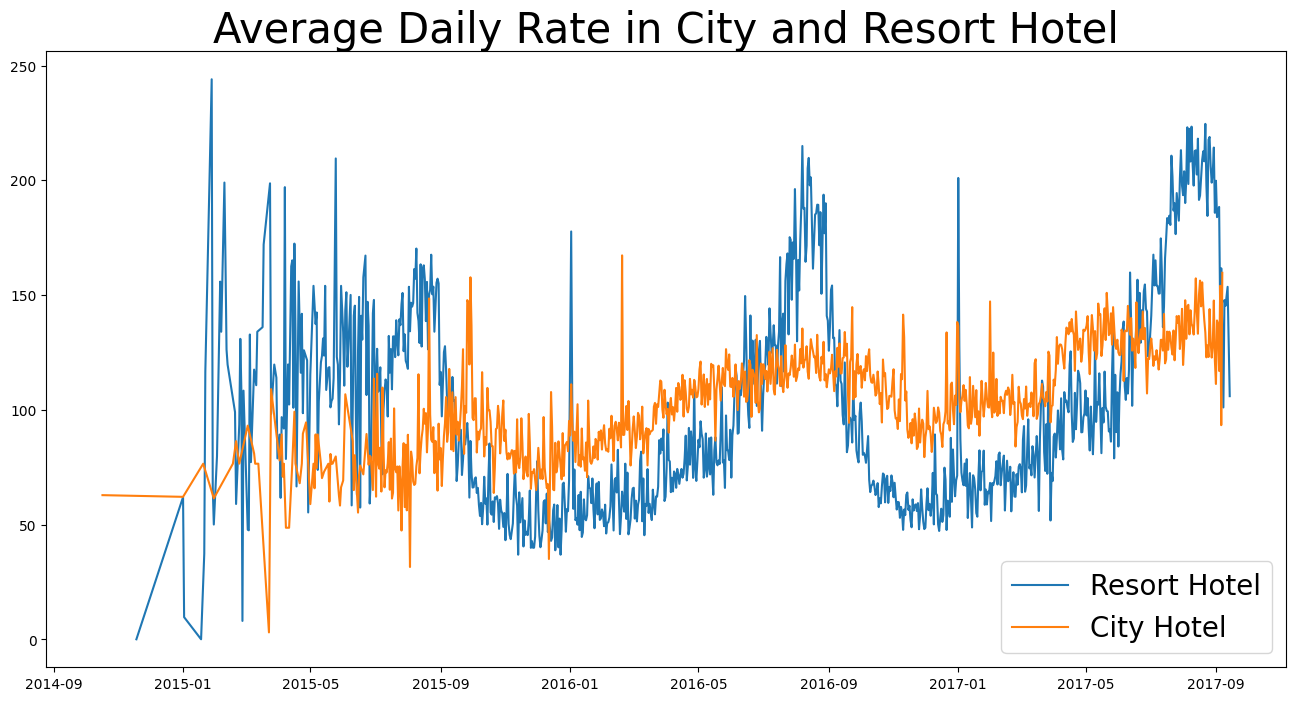

In [36]:
plt.figure(figsize=(16,8))
plt.title('Average Daily Rate in City and Resort Hotel', fontsize=30)
plt.plot(resort_hotel.index,resort_hotel['adr'],label='Resort Hotel')
plt.plot(city_hotel.index,city_hotel[['adr']],label='City Hotel')
plt.legend(fontsize=20)
plt.show()

#### the spikes could be on weekend or any occasion on which price gets higher
#### We have  less data for the year 2014, 2015, 2017 and 2018
#### so it is understood that prices of resort hotel is much higher than city hotels

Text(0.5, 1.0, 'Reservation status per month')

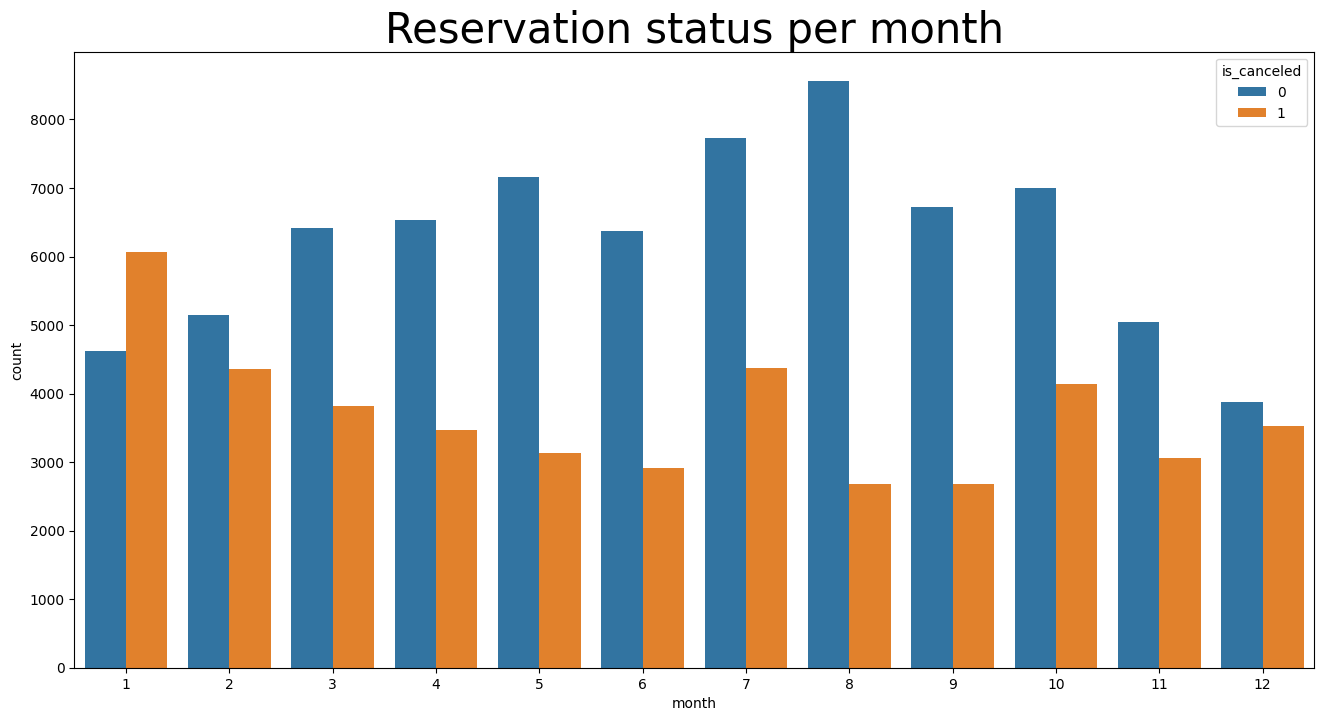

In [39]:
df['month']=df['reservation_status_date'].dt.month
plt.figure(figsize=(16,8))
sns.countplot(x='month',hue='is_canceled',data=df)
plt.title('Reservation status per month',fontsize=30)

In [42]:
pd.crosstab(df['month'], df['is_canceled'])

is_canceled,0,1
month,,
1,4620,6061
2,5140,4358
3,6410,3820
4,6529,3470
5,7166,3138
6,6366,2912
7,7737,4369
8,8561,2688
9,6727,2676


Text(0, 0.5, 'Number of Cancellations')

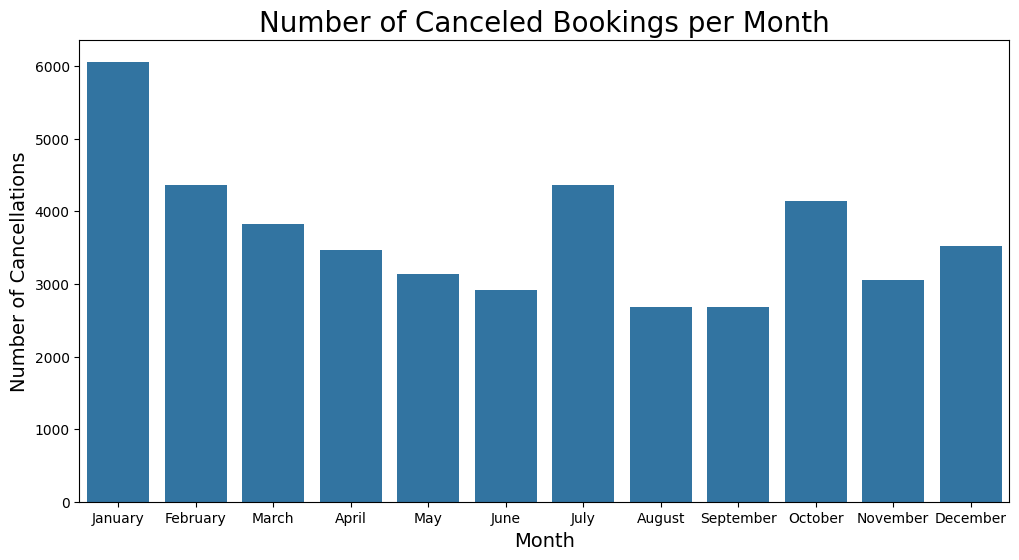

In [9]:
df['month_name'] = df['reservation_status_date'].dt.month_name()
plt.figure(figsize=(12,6))
sns.countplot(x='month_name', data=df[df['is_canceled']==1], order=[
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])
plt.title('Number of Canceled Bookings per Month', fontsize=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Cancellations', fontsize=14)

#### Cancelation in January month is higher than reserved
#### and in August Month cancelation is less among all 

([<matplotlib.patches.Wedge at 0x1a02fed5430>,
 [Text(-0.6485414980270044, 0.888478432679651, 'PRT'),
  Text(-0.12452901505974424, -1.0929284168728757, 'GBR'),
  Text(0.2795827699816853, -1.0638766257087182, 'ESP'),
  Text(0.6082427774650023, -0.9165373553007318, 'FRA'),
  Text(0.8244337697170071, -0.7282231521657391, 'ITA'),
  Text(0.9549224064682716, -0.5460065911917595, 'DEU'),
  Text(1.0312598327523899, -0.38275730868464564, 'IRL'),
  Text(1.0729025706347506, -0.24265216653750293, 'BRA'),
  Text(1.0926161903610716, -0.12723938290033737, 'USA'),
  Text(1.0992090719340442, -0.041706308610296686, 'BEL')],
 [Text(-0.35374990801472966, 0.48462459964344595, '70.07'),
  Text(-0.06792491730531504, -0.5961427728397503, '6.25'),
  Text(0.1524996927172829, -0.5802963412956644, '5.54'),
  Text(0.331768787708183, -0.49992946652767184, '4.93'),
  Text(0.44969114711836744, -0.39721262845403943, '3.39'),
  Text(0.5208667671645117, -0.297821777013687, '3.10'),
  Text(0.5625053633194853, -0.20877671

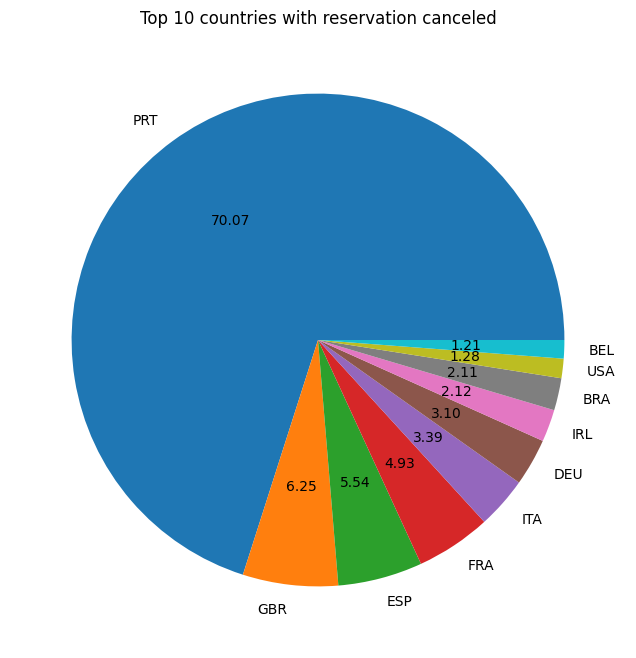

In [22]:
#Cancelation in countries, top 10 countries
canceled_data=df[df['is_canceled']==1]
top_10_country=canceled_data['country'].value_counts()[:10]
plt.figure(figsize=(8,8))
plt.title("Top 10 countries with reservation canceled")
plt.pie(top_10_country, autopct='%.2f',labels=top_10_country.index)

#### Suggestion can be in Portugal Country the hotel management team should decrease the prices or increase the facility or offers or marketing campaigns to reduce the cancelation 

In [23]:
df['market_segment'].value_counts()

market_segment
Online TA        56402
Offline TA/TO    24159
Groups           19806
Direct           12448
Corporate         5111
Complementary      734
Aviation           237
Name: count, dtype: int64

In [24]:
df['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.474377
Offline TA/TO    0.203193
Groups           0.166581
Direct           0.104696
Corporate        0.042987
Complementary    0.006173
Aviation         0.001993
Name: proportion, dtype: float64

#### Through Online Travel Agents 47% of reservations are done

In [25]:
canceled_data['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.469696
Groups           0.273985
Offline TA/TO    0.187466
Direct           0.043486
Corporate        0.022151
Complementary    0.002038
Aviation         0.001178
Name: proportion, dtype: float64

#### even through online TA's 46% of cancelation have done
#### Possible reasons can be photos shown on the online site could be not matching with the real site

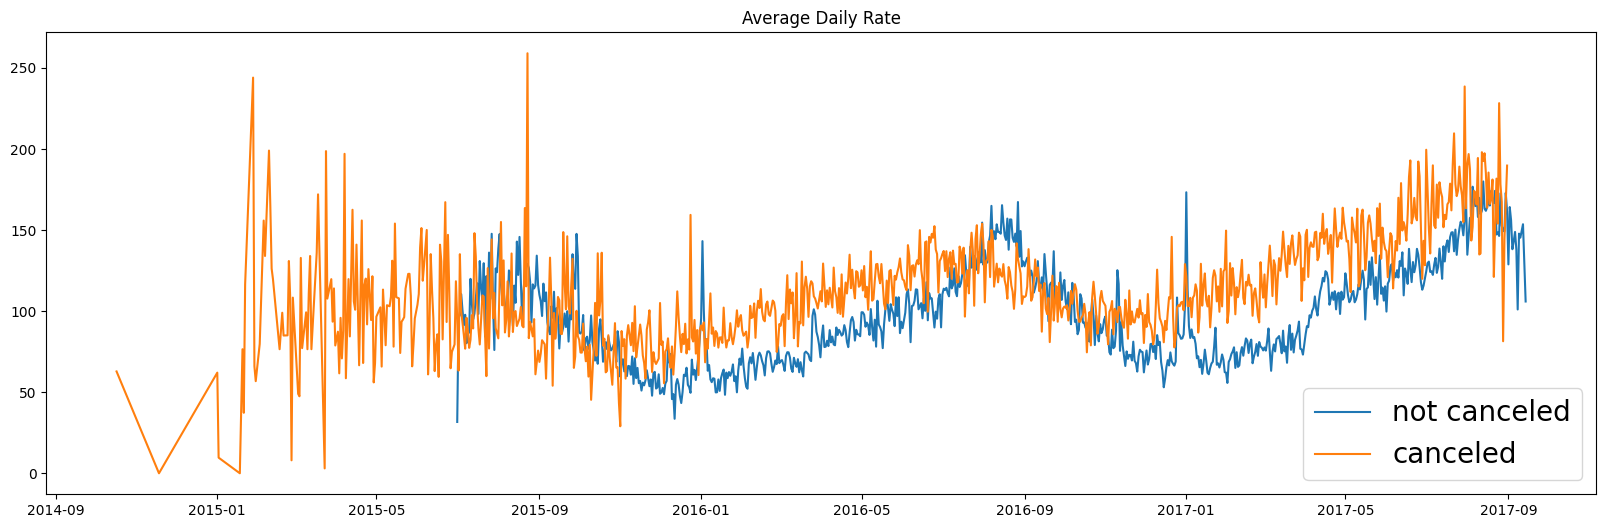

In [38]:
canceled_df_adr = canceled_data.groupby('reservation_status_date')[['adr']].mean()
canceled_df_adr.reset_index(inplace = True)
canceled_df_adr.sort_values('reservation_status_date', inplace = True)

not_canceled_data=df[df['is_canceled']==0]
not_canceled_df_adr = not_canceled_data.groupby('reservation_status_date')[['adr']].mean()
not_canceled_df_adr.reset_index(inplace = True)
not_canceled_df_adr.sort_values('reservation_status_date', inplace = True)


plt.figure(figsize = (20,6))
plt.title('Average Daily Rate')
plt.plot(not_canceled_df_adr['reservation_status_date'], not_canceled_df_adr['adr'], label = 'not canceled')
plt.plot(canceled_df_adr['reservation_status_date'], canceled_df_adr['adr'], label = 'canceled')
plt.legend(fontsize=20)
plt.show()

#### ADR affects cancelation the most